# `coSMicQC` in a nutshell

This notebook demonstrates various capabilities of `coSMicQC` using examples.

,Metadata_ImageNumber,Image_Metadata_Plate_x,Metadata_number_of_singlecells,Image_Metadata_Site_x,Image_Metadata_Well_x,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Cytoplasm_AreaShape_Area,...,Image_Threshold_SumOfEntropies_Cells,Image_Threshold_SumOfEntropies_Nuclei,Image_Threshold_WeightedVariance_Cells,Image_Threshold_WeightedVariance_Nuclei,Image_URL_DAPI,Image_URL_GFP,Image_URL_RFP,Image_Width_DAPI,Image_Width_GFP,Image_Width_RFP
0,1,Plate_2,44,1,A12,1,1,2,2,21024.0,...,-12.181288,-11.699993,0.992624,0.657791,,,,1224,1224,1224
1,1,Plate_2,44,1,A12,4,4,7,7,12754.0,...,-12.181288,-11.699993,0.992624,0.657791,,,,1224,1224,1224
2,1,Plate_2,44,1,A12,7,7,10,10,23976.0,...,-12.181288,-11.699993,0.992624,0.657791,,,,1224,1224,1224
3,1,Plate_2,44,1,A12,8,8,12,12,19374.0,...,-12.181288,-11.699993,0.992624,0.657791,,,,1224,1224,1224
4,1,Plate_2,44,1,A12,9,9,13,13,27385.0,...,-12.181288,-11.699993,0.992624,0.657791,,,,1224,1224,1224

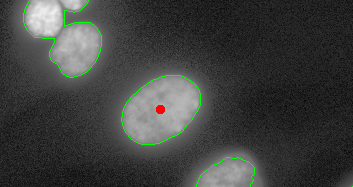
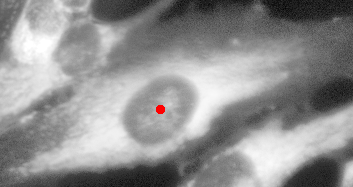
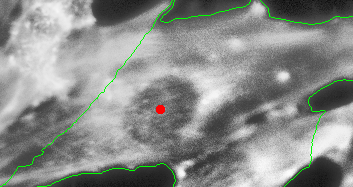
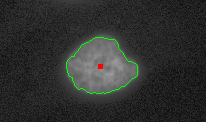
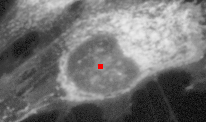
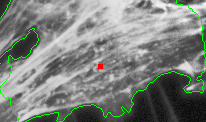
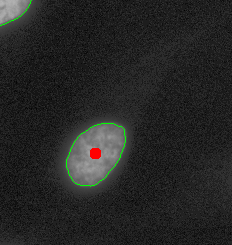
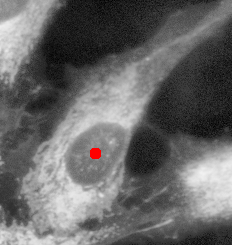
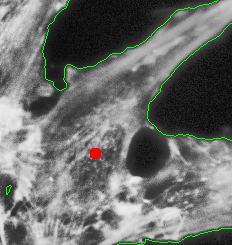
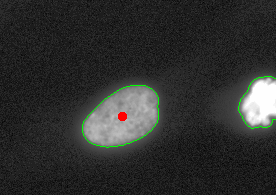
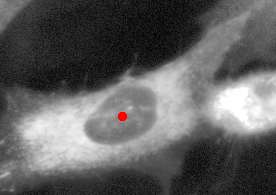
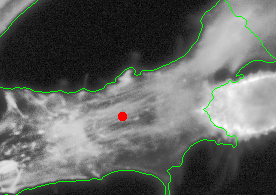
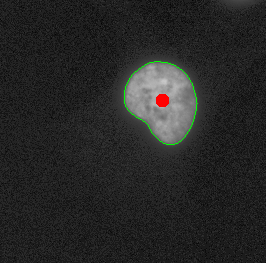
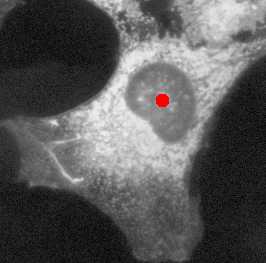
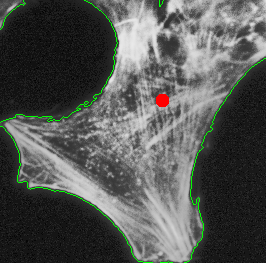

In [1]:
import pathlib

import pandas as pd
from cytodataframe import CytoDataFrame

import cosmicqc

# set a path for the parquet-based dataset
# (in this case, CellProfiler SQLite data processed by CytoTable)
data_path = (
    "../../../tests/data/cytotable/NF1_cellpainting_data/"
    "Plate_2_with_image_data.parquet"
)

# set a context directory for images associated with the dataset
image_context_dir = pathlib.Path(data_path).parent / "Plate_2_images"
mask_context_dir = pathlib.Path(data_path).parent / "Plate_2_masks"

# create a cosmicqc CytoDataFrame (single-cell DataFrame)
scdf = CytoDataFrame(
    data=data_path,
    data_context_dir=image_context_dir,
    data_mask_context_dir=mask_context_dir,
)

# display the dataframe
scdf.head()

In [2]:
# Identify which rows include outliers for a given threshold definition
# which references a column name and a z-score number which is considered
# the limit.
cosmicqc.analyze.identify_outliers(
    df=scdf,
    feature_thresholds={"Nuclei_AreaShape_Area": -1},
).sort_values()

0       False
1085    False
1083    False
1082    False
1080    False
        ...  
572      True
571      True
567      True
280      True
856      True
Name: cqc.custom.Z_Score.Nuclei_AreaShape_Area, Length: 1714, dtype: bool

In [3]:
# Show the number of outliers given a column name and a specified threshold
# via the `feature_thresholds` parameter and the `find_outliers` function.
cosmicqc.analyze.find_outliers(
    df=scdf,
    metadata_columns=["Metadata_ImageNumber", "Image_Metadata_Plate_x"],
    feature_thresholds={"Nuclei_AreaShape_Area": -1},
)

Number of outliers: 328 (19.14%)
Outliers Range:
Nuclei_AreaShape_Area Min: 734.0
Nuclei_AreaShape_Area Max: 1904.0


In [4]:
# create a labeled dataset which includes z-scores and whether those scores
# are interpreted as outliers or inliers. We use pre-defined threshold sets
# loaded from defaults (cosmicqc can accept user-defined thresholds too!).
labeled_scdf = cosmicqc.analyze.label_outliers(
    df=scdf,
    include_threshold_scores=True,
)

# show the dataframe rows with outlier labels and z-scores
labeled_scdf.head()

Clamping filter plot threshold for column 'cqc.small_and_low_formfactor_nuclei.Z_Score.Nuclei_AreaShape_Area' from -1.0 to -0.4024909442289411 because it is outside data range [-0.4024909442289411, 1.1534456464349674].
Clamping filter plot threshold for column 'cqc.elongated_nuclei.Z_Score.Nuclei_AreaShape_Eccentricity' from 2.0 to 0.9612175587727715 because it is outside data range [-0.6594004045224938, 0.9612175587727715].
Clamping filter plot threshold for column 'cqc.large_nuclei.Z_Score.Nuclei_AreaShape_Area' from 2.0 to 1.1534456464349674 because it is outside data range [-0.4024909442289411, 1.1534456464349674].
Clamping filter plot threshold for column 'cqc.large_nuclei.Z_Score.Nuclei_AreaShape_FormFactor' from -2.0 to -1.2807945533819753 because it is outside data range [-1.2807945533819753, 0.2199034032067771].


,Metadata_ImageNumber,Image_Metadata_Plate_x,Metadata_number_of_singlecells,Image_Metadata_Site_x,Image_Metadata_Well_x,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Cytoplasm_AreaShape_Area,...,Image_Width_RFP,cqc.custom.Z_Score.Nuclei_AreaShape_Area,cqc.small_and_low_formfactor_nuclei.Z_Score.Nuclei_AreaShape_Area,cqc.small_and_low_formfactor_nuclei.Z_Score.Nuclei_AreaShape_FormFactor,cqc.small_and_low_formfactor_nuclei.is_outlier,cqc.elongated_nuclei.Z_Score.Nuclei_AreaShape_Eccentricity,cqc.elongated_nuclei.is_outlier,cqc.large_nuclei.Z_Score.Nuclei_AreaShape_Area,cqc.large_nuclei.Z_Score.Nuclei_AreaShape_FormFactor,cqc.large_nuclei.is_outlier
0,1,Plate_2,44,1,A12,1,1,2,2,21024.0,...,1224,0.848820,0.848820,0.219903,False,0.498274,False,0.848820,0.219903,False
1,1,Plate_2,44,1,A12,4,4,7,7,12754.0,...,1224,-0.252521,-0.252521,-1.280795,False,-0.659400,False,-0.252521,-1.280795,False
2,1,Plate_2,44,1,A12,7,7,10,10,23976.0,...,1224,-0.402491,-0.402491,-0.325652,False,0.819165,False,-0.402491,-0.325652,False
3,1,Plate_2,44,1,A12,8,8,12,12,19374.0,...,1224,0.329549,0.329549,-0.268920,False,0.961218,False,0.329549,-0.268920,False
4,1,Plate_2,44,1,A12,9,9,13,13,27385.0,...,1224,1.153446,1.153446,0.028845,False,-0.372891,False,1.153446,0.028845,False


In [ ]:
# show cropped images through CytoDataFrame from the dataset to help analyze outliers
# labeled_scdf._enbable_debug_mode()
labeled_scdf.sort_values(by="cqc.large_nuclei.is_outlier", ascending=False)[
    [
        "Metadata_ImageNumber",
        "Metadata_Cells_Number_Object_Number",
        "cqc.large_nuclei.is_outlier",
        "Image_FileName_GFP",
        "Image_FileName_RFP",
        "Image_FileName_DAPI",
    ]
]

In [6]:
# One can convert from cosmicqc.CytoDataFrame to pd.DataFrame's
# (when or if needed!)
df = pd.DataFrame(scdf)
print(type(df))
df

<class 'pandas.core.frame.DataFrame'>


,Metadata_ImageNumber,Image_Metadata_Plate_x,Metadata_number_of_singlecells,Image_Metadata_Site_x,Image_Metadata_Well_x,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Cytoplasm_AreaShape_Area,...,Image_URL_RFP,Image_Width_DAPI,Image_Width_GFP,Image_Width_RFP,cqc.custom.Z_Score.Nuclei_AreaShape_Area,cqc.small_and_low_formfactor_nuclei.Z_Score.Nuclei_AreaShape_Area,cqc.small_and_low_formfactor_nuclei.Z_Score.Nuclei_AreaShape_FormFactor,cqc.elongated_nuclei.Z_Score.Nuclei_AreaShape_Eccentricity,cqc.large_nuclei.Z_Score.Nuclei_AreaShape_Area,cqc.large_nuclei.Z_Score.Nuclei_AreaShape_FormFactor
0,1,Plate_2,44,1,A12,1,1,2,2,21024.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,0.848820,0.848820,0.219903,0.498274,0.848820,0.219903
1,1,Plate_2,44,1,A12,4,4,7,7,12754.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,-0.252521,-0.252521,-1.280795,-0.659400,-0.252521,-1.280795
2,1,Plate_2,44,1,A12,7,7,10,10,23976.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,-0.402491,-0.402491,-0.325652,0.819165,-0.402491,-0.325652
3,1,Plate_2,44,1,A12,8,8,12,12,19374.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,0.329549,0.329549,-0.268920,0.961218,0.329549,-0.268920
4,1,Plate_2,44,1,A12,9,9,13,13,27385.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,1.153446,1.153446,0.028845,-0.372891,1.153446,0.028845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709,128,Plate_2,59,4,H7,10,10,14,14,24942.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,0.598557,0.598557,-0.280063,0.923075,0.598557,-0.280063
1710,128,Plate_2,59,4,H7,11,11,15,15,6627.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,-0.716490,-0.716490,0.068293,0.650830,-0.716490,0.068293
1711,128,Plate_2,59,4,H7,12,12,16,16,11216.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,1.187189,1.187189,0.833264,-0.752359,1.187189,0.833264
1712,128,Plate_2,59,4,H7,13,13,17,17,15279.0,...,file:/home/jenna/nf1_cellpainting_data/1.cellp...,1224,1224,1224,-0.699619,-0.699619,0.534479,-0.747030,-0.699619,0.534479
